#### Mirror Symmetry Experiment Implementation

#### Import and Generate dataset

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [13]:
# Generate all possible 6-bit binary patterns
patterns = np.array(list(itertools.product([0, 1], repeat=6)))

print("Number of patterns:", len(patterns))
print(patterns[:10])

Number of patterns: 64
[[0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 0 0 0 1 1]
 [0 0 0 1 0 0]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]
 [0 0 0 1 1 1]
 [0 0 1 0 0 0]
 [0 0 1 0 0 1]]


#### Create the labels

In [14]:
def is_mirror_symmetric(pattern):
    left = pattern[:3]
    right = pattern[3:]
    
    return int(np.array_equal(left, right[::-1]))

example_1 = np.array([1, 0, 1, 1, 0, 1])
example_2 = np.array([1, 0, 0, 1, 1, 0])

print(is_mirror_symmetric(example_1))
print(is_mirror_symmetric(example_2))

1
0


In [15]:
y = np.array([
    is_mirror_symmetric(pattern)
    for pattern in patterns
])

print("Symmetric patterns:", np.sum(y == 1))
print("Non-symmetric patterns:", np.sum(y == 0))

Symmetric patterns: 8
Non-symmetric patterns: 56


#### Inspect the dataset

In [16]:
for i in range(10):
    print(patterns[i], "→", y[i])

[0 0 0 0 0 0] → 1
[0 0 0 0 0 1] → 0
[0 0 0 0 1 0] → 0
[0 0 0 0 1 1] → 0
[0 0 0 1 0 0] → 0
[0 0 0 1 0 1] → 0
[0 0 0 1 1 0] → 0
[0 0 0 1 1 1] → 0
[0 0 1 0 0 0] → 0
[0 0 1 0 0 1] → 0


#### Initialize the network

In [17]:
np.random.seed(42)

input_size = 6
hidden_size = 2
output_size = 1

W1 = np.random.uniform(-0.5, 0.5, (input_size, hidden_size))
b1 = np.zeros((1, hidden_size))

W2 = np.random.uniform(-0.5, 0.5, (hidden_size, output_size))
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (6, 2)
W2 shape: (2, 1)


#### Forward Propagation

In [18]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)

def forward(X):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    return a1, a2

#### Back Propagation

In [19]:
learning_rate = 0.5
epochs = 10000

loss_history = []

X = patterns.astype(float)
Y = y.reshape(-1, 1).astype(float)

for epoch in range(epochs):

    # -----------------
    # Forward pass
    # -----------------
    a1, a2 = forward(X)

    # -----------------
    # Calculate loss
    # -----------------
    loss = np.mean((a2 - Y) ** 2)
    loss_history.append(loss)

    # -----------------
    # Backward pass
    # -----------------
    delta2 = (a2 - Y) * sigmoid_derivative(a2)

    dW2 = a1.T @ delta2
    db2 = np.sum(delta2, axis=0, keepdims=True)

    delta1 = (delta2 @ W2.T) * sigmoid_derivative(a1)

    dW1 = X.T @ delta1
    db1 = np.sum(delta1, axis=0, keepdims=True)

    # -----------------
    # Update weights
    # -----------------
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.6f}")

Epoch 0: Loss = 0.238864
Epoch 1000: Loss = 0.090033
Epoch 2000: Loss = 0.088533
Epoch 3000: Loss = 0.087692
Epoch 4000: Loss = 0.087481
Epoch 5000: Loss = 0.087388
Epoch 6000: Loss = 0.087335
Epoch 7000: Loss = 0.087300
Epoch 8000: Loss = 0.087275
Epoch 9000: Loss = 0.087257


#### Plot learning curve

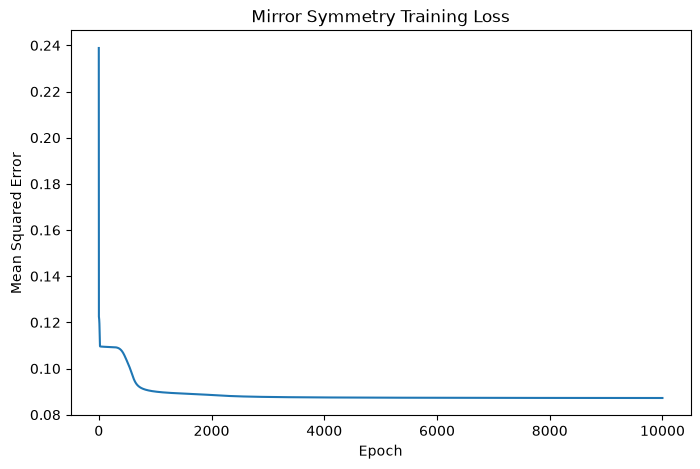

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Mirror Symmetry Training Loss")

plt.show()

#### Evaluate the network

In [21]:
_, predictions = forward(X)

predicted_classes = (predictions >= 0.5).astype(int)

accuracy = np.mean(predicted_classes == Y)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8906


In [24]:
actual = Y.flatten()
predicted = predicted_classes.flatten()
probability = predictions.flatten()

for i in range(len(X)):
    print(
        X[i].astype(int),
        "Actual:", int(actual[i]),
        "Predicted:", int(predicted[i]),
        "Probability:", round(float(probability[i]), 4)
    )

[0 0 0 0 0 0] Actual: 1 Predicted: 0 Probability: 0.4995
[0 0 0 0 0 1] Actual: 0 Predicted: 0 Probability: 0.0844
[0 0 0 0 1 0] Actual: 0 Predicted: 0 Probability: 0.4995
[0 0 0 0 1 1] Actual: 0 Predicted: 0 Probability: 0.0844
[0 0 0 1 0 0] Actual: 0 Predicted: 0 Probability: 0.0932
[0 0 0 1 0 1] Actual: 0 Predicted: 0 Probability: 0.0838
[0 0 0 1 1 0] Actual: 0 Predicted: 0 Probability: 0.0842
[0 0 0 1 1 1] Actual: 0 Predicted: 0 Probability: 0.0838
[0 0 1 0 0 0] Actual: 0 Predicted: 0 Probability: 0.0932
[0 0 1 0 0 1] Actual: 0 Predicted: 0 Probability: 0.0838
[0 0 1 0 1 0] Actual: 0 Predicted: 0 Probability: 0.0842
[0 0 1 0 1 1] Actual: 0 Predicted: 0 Probability: 0.0838
[0 0 1 1 0 0] Actual: 1 Predicted: 1 Probability: 0.9686
[0 0 1 1 0 1] Actual: 0 Predicted: 0 Probability: 0.0866
[0 0 1 1 1 0] Actual: 0 Predicted: 0 Probability: 0.0861
[0 0 1 1 1 1] Actual: 0 Predicted: 0 Probability: 0.0838
[0 1 0 0 0 0] Actual: 0 Predicted: 0 Probability: 0.4995
[0 1 0 0 0 1] Actual: 0 Predict